<a href="https://colab.research.google.com/github/agarwalpratik/aiml/blob/main/Employee_Turnover_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Employee Turnover Analytics**

Portobello Tech is an app innovator who has devised an intelligent way of predicting employee turnover within the company. It periodically evaluates employees' work details, including the number of projects they worked on, average monthly working hours, time spent in the company, promotions in the last five years, and salary level.
Data from prior evaluations shows the employees’ satisfaction in the workplace. The data could be used to identify patterns in work style and their interest in continuing to work for the company.
The HR Department owns the data and uses it to predict employee turnover. Employee turnover refers to the total number of workers who leave a company over time.
As the ML Developer assigned to the HR Department, you have been asked to create ML programs to:
1.	Perform data quality checks by checking for missing values, if any.
2.	Understand what factors contributed most to employee turnover at EDA.
3.	Perform clustering of employees who left based on their satisfaction and evaluation.
4.	Handle the left Class Imbalance using the SMOTE technique.
5.	Perform k-fold cross-validation model training and evaluate performance.
6.	Identify the best model and justify the evaluation metrics used.
7.	Suggest various retention strategies for targeted employees.


In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('HR_comma_sep.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


**1.	Perform data quality checks by checking for missing values, if any.bold text**

In [4]:
data.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


In [5]:
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [6]:
data.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


**
2.1.	Draw a heatmap of the correlation matrix between all numerical features or columns in the data.
**

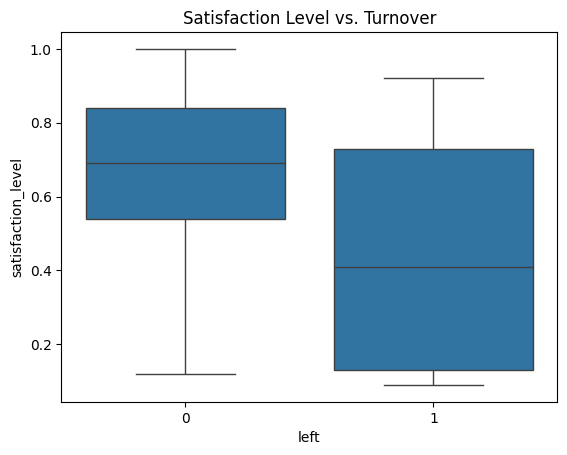

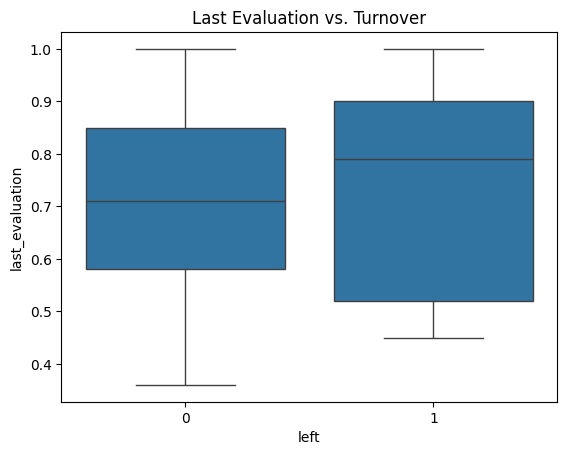

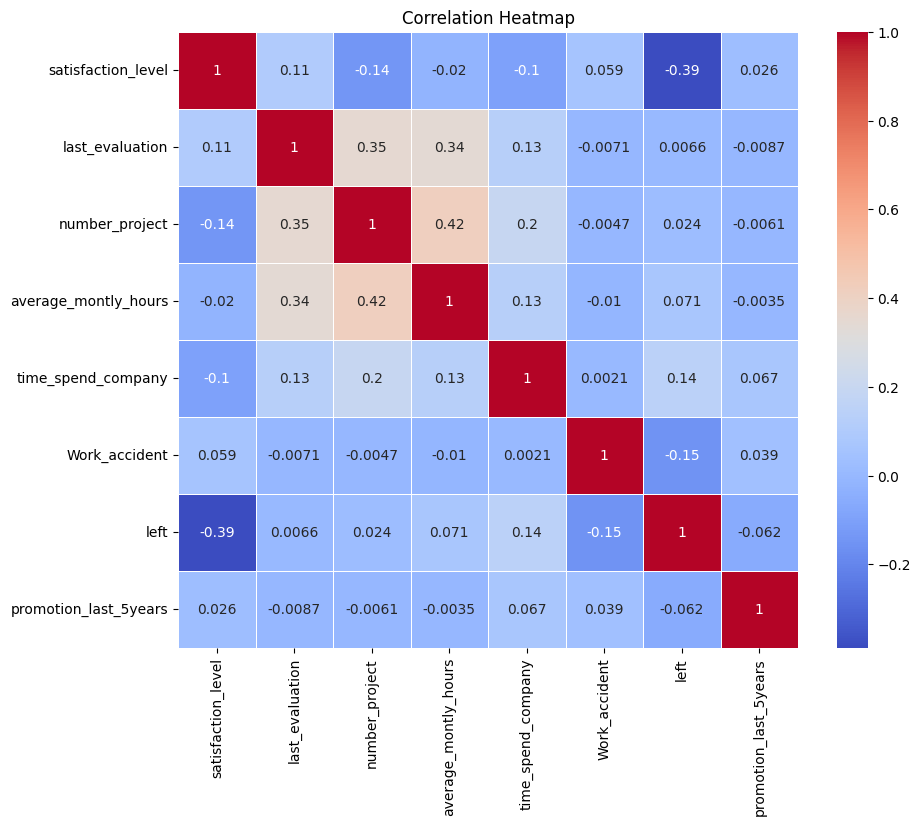

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

data_2 = data.iloc[:,0:8]

# Plot distributions of numeric features based on turnover
sns.boxplot(x='left', y='satisfaction_level', data=data_2)
plt.title('Satisfaction Level vs. Turnover')
plt.show()

sns.boxplot(x='left', y='last_evaluation', data=data_2)
plt.title('Last Evaluation vs. Turnover')
plt.show()

# Correlation heatmap
corr = data_2.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

2.2.	Draw the distribution plot of:

■	Employee Satisfaction (use column satisfaction_level)

■	Employee Evaluation (use column last_evaluation)

■	Employee Average Monthly Hours (use column average_montly_hours)


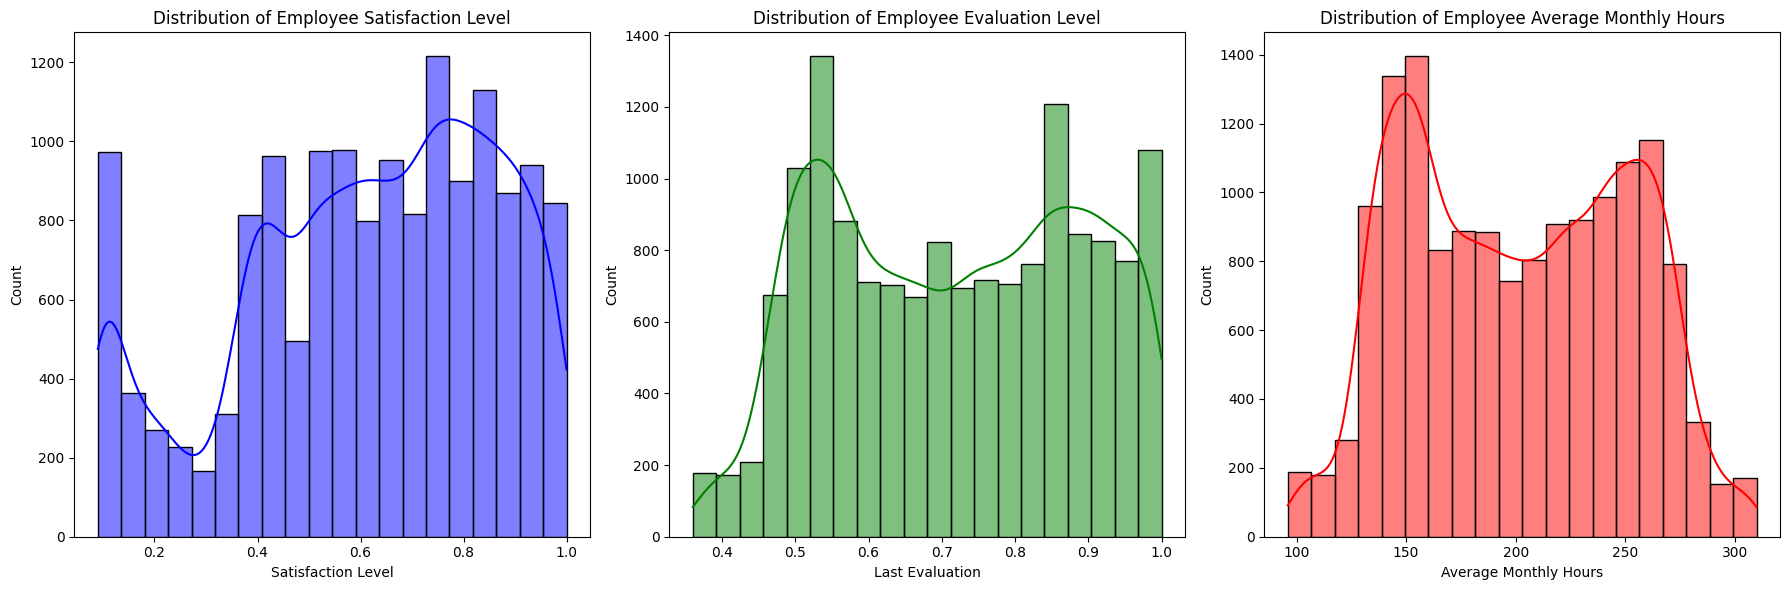

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(18, 6))

# Employee Satisfaction distribution
plt.subplot(1, 3, 1)
sns.histplot(data['satisfaction_level'], kde=True, bins=20, color='blue')
plt.title('Distribution of Employee Satisfaction Level')
plt.xlabel('Satisfaction Level')

# Employee Evaluation distribution
plt.subplot(1, 3, 2)
sns.histplot(data['last_evaluation'], kde=True, bins=20, color='green')
plt.title('Distribution of Employee Evaluation Level')
plt.xlabel('Last Evaluation')

# Employee Average Monthly Hours distribution
plt.subplot(1, 3, 3)
sns.histplot(data['average_montly_hours'], kde=True, bins=20, color='red')
plt.title('Distribution of Employee Average Monthly Hours')
plt.xlabel('Average Monthly Hours')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

2.3.	Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.

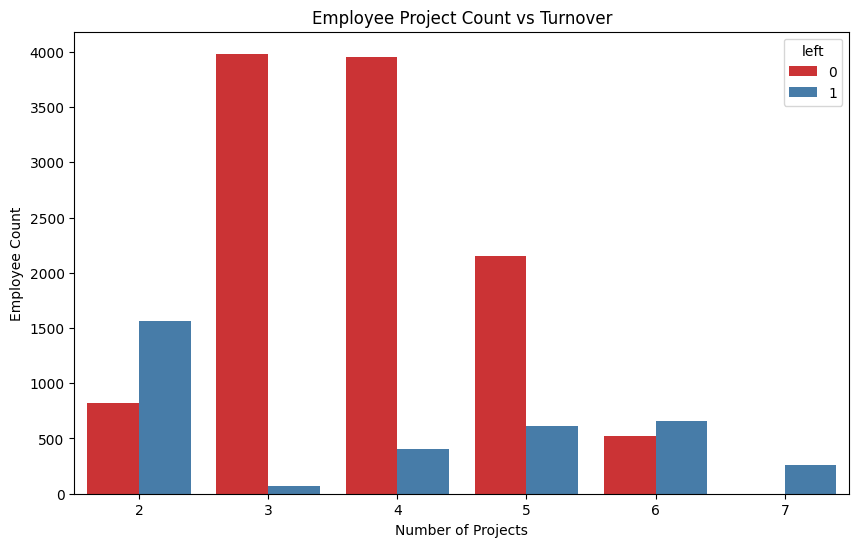

In [10]:
# Plotting a bar plot of employee project count with hue based on whether they left (1) or stayed (0)
plt.figure(figsize=(10,6))

# Bar plot
sns.countplot(x='number_project', hue='left', data=data, palette='Set1')
plt.title('Employee Project Count vs Turnover')
plt.xlabel('Number of Projects')
plt.ylabel('Employee Count')

# Display the plot
plt.show()


Lower project counts (2-3 projects): Employees with fewer projects are more likely to stay with the company.

Moderate project counts (4-5 projects): Employees with 4 or 5 projects are less likely to leave compared to those with fewer or more projects.

Higher project counts (6-7 projects): Employees with a higher number of projects (6 or more) tend to have a higher turnover rate, indicating potential burnout or work overload.

This suggests that employees who are either underworked or overloaded tend to leave more frequently, while those with a moderate workload tend to stay.

************************************************************************



Perform clustering of employees who left based on their satisfaction and evaluation.

3.1.	Choose columns satisfaction_level, last_evaluation, and left.

3.2.	Do K-means clustering of employees who left the company into 3 clusters?

3.3.	Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.


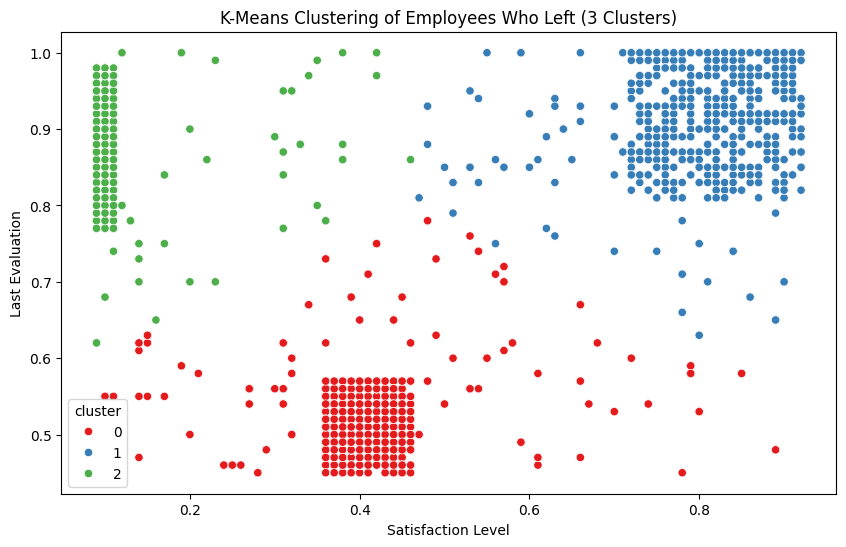

array([[0.41230354, 0.51726455],
       [0.80803109, 0.91641451],
       [0.11132055, 0.87088392]])

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 3.1 Select relevant columns: satisfaction_level, last_evaluation, and left
data_left = data[data['left'] == 1][['satisfaction_level', 'last_evaluation']]

# Scale the data for better clustering performance
scaler = StandardScaler()
data_left_scaled = scaler.fit_transform(data_left)

# 3.2 Perform K-means clustering into 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
data_left['cluster'] = kmeans.fit_predict(data_left_scaled)

# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='satisfaction_level', y='last_evaluation', hue='cluster', palette='Set1', data=data_left)
plt.title('K-Means Clustering of Employees Who Left (3 Clusters)')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.show()

# Display the cluster centroids
centroids = kmeans.cluster_centers_
centroids_scaled = scaler.inverse_transform(centroids)
centroids_scaled




The K-means clustering divided the employees who left into three distinct clusters based on their satisfaction level and last evaluation. The centroids (average values for each cluster) are as follows:


Cluster 0:

Satisfaction Level: 0.41

Last Evaluation: 0.52

Employees in this cluster have moderate satisfaction and average evaluation scores, which could indicate stable but unengaged employees.


Cluster 1:

Satisfaction Level: 0.81

Last Evaluation: 0.92

These employees had high satisfaction and high evaluation scores, yet they still left. This could suggest possible overworking or lack of advancement opportunities despite good performance.


Cluster 2:

Satisfaction Level: 0.11

Last Evaluation: 0.87


This cluster represents employees who had very low satisfaction but relatively high evaluation scores. It could indicate dissatisfaction despite performing well, possibly due to management issues or lack of personal growth.


These clusters can help the HR team understand different reasons for employee turnover and tailor retention strategies accordingly.

*************************************************************************

Handle the left Class Imbalance using the SMOTE technique.

4.1.	Pre-process the data by converting categorical columns to numerical columns by:

■	Separating categorical variables and numeric variables

■	Applying get_dummies() to the categorical variables

■	Combining categorical variables and numeric variables

4.2.	Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.

4.3.	Upsample the train dataset using the SMOTE technique from the imblearn module.


In [13]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

# 4.1 Pre-process the data
# Separate categorical and numerical variables
categorical_vars = ['sales', 'salary']
numeric_vars = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']

# Convert categorical variables to dummy/indicator variables
data_categorical = pd.get_dummies(data[categorical_vars], drop_first=True)

# Combine categorical and numeric variables
data_processed = pd.concat([data[numeric_vars], data_categorical, data['left']], axis=1)

# 4.2 Stratified split of the dataset to train (80%) and test (20%) sets
X = data_processed.drop('left', axis=1)
y = data_processed['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

# 4.3 Upsample the training dataset using SMOTE
smote = SMOTE(random_state=123)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Checking the class distribution after applying SMOTE
y_train_smote.value_counts()


,count
left,
0,9142
1,9142


****************************************************************
Perform 5-fold cross-validation model training and evaluate performance.

5.1.	Train a logistic regression model, apply a 5-fold CV, and plot the classification report.

5.2.	Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.

5.3.	Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.


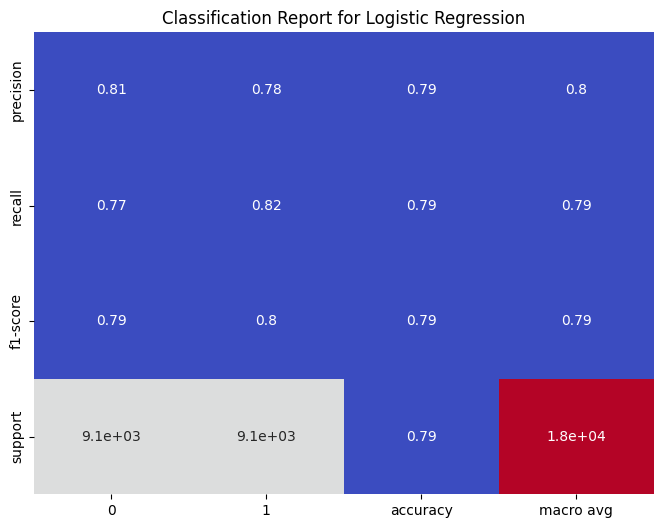



Model: Logistic Regression

Accuracy: 0.7950

Classification Report:
{'0': {'precision': 0.8082771235852292, 'recall': 0.7733537519142419, 'f1-score': 0.7904298731063782, 'support': 9142.0}, '1': {'precision': 0.7827409038481703, 'recall': 0.8165609275869613, 'f1-score': 0.7992933240537502, 'support': 9142.0}, 'accuracy': 0.7949573397506016, 'macro avg': {'precision': 0.7955090137166998, 'recall': 0.7949573397506016, 'f1-score': 0.7948615985800642, 'support': 18284.0}, 'weighted avg': {'precision': 0.7955090137166998, 'recall': 0.7949573397506016, 'f1-score': 0.7948615985800642, 'support': 18284.0}}
Confusion Matrix:
[[7070 2072]
 [1677 7465]]




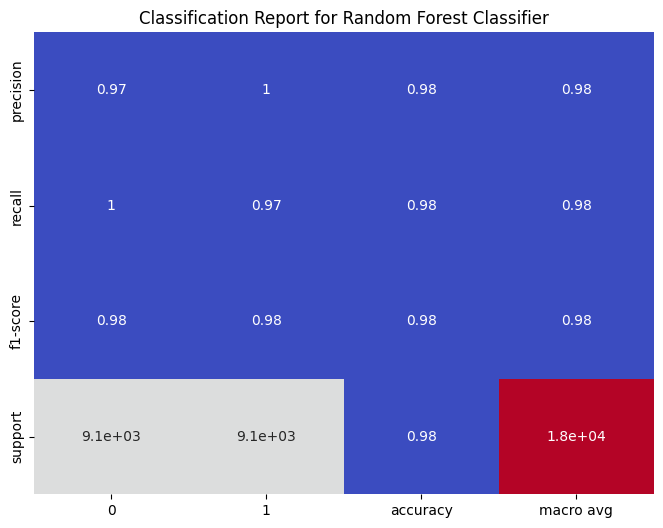



Model: Random Forest Classifier

Accuracy: 0.9837

Classification Report:
{'0': {'precision': 0.9726378794356563, 'recall': 0.9954058192955589, 'f1-score': 0.9838901502865175, 'support': 9142.0}, '1': {'precision': 0.9952956989247311, 'recall': 0.9719973747538831, 'f1-score': 0.9835085777531821, 'support': 9142.0}, 'accuracy': 0.983701597024721, 'macro avg': {'precision': 0.9839667891801938, 'recall': 0.983701597024721, 'f1-score': 0.9836993640198498, 'support': 18284.0}, 'weighted avg': {'precision': 0.9839667891801936, 'recall': 0.983701597024721, 'f1-score': 0.9836993640198498, 'support': 18284.0}}
Confusion Matrix:
[[9100   42]
 [ 256 8886]]




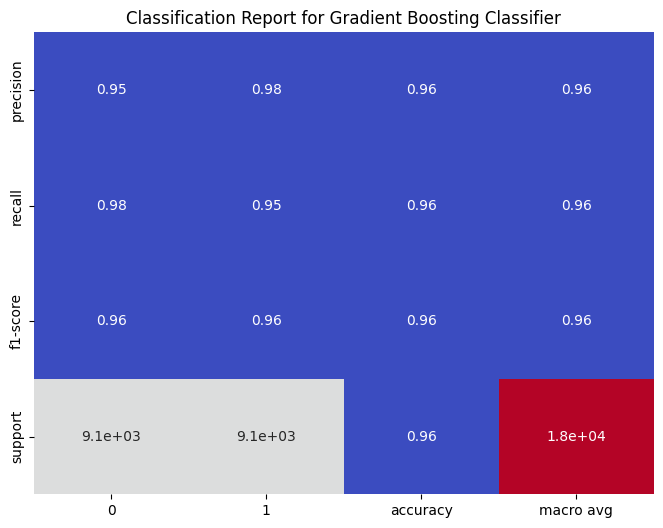



Model: Gradient Boosting Classifier

Accuracy: 0.9630

Classification Report:
{'0': {'precision': 0.9497396663478908, 'recall': 0.9776854080070007, 'f1-score': 0.963509944483372, 'support': 9142.0}, '1': {'precision': 0.977008903414854, 'recall': 0.9482607744476045, 'f1-score': 0.9624202053844019, 'support': 9142.0}, 'accuracy': 0.9629730912273026, 'macro avg': {'precision': 0.9633742848813724, 'recall': 0.9629730912273026, 'f1-score': 0.9629650749338869, 'support': 18284.0}, 'weighted avg': {'precision': 0.9633742848813723, 'recall': 0.9629730912273026, 'f1-score': 0.9629650749338869, 'support': 18284.0}}
Confusion Matrix:
[[8938  204]
 [ 473 8669]]




In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Function to evaluate model performance
def evaluate_model_performance(y_true, y_pred, model_name):
    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Classification Report
    report = classification_report(y_true, y_pred, output_dict=True)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Convert the dictionary to a DataFrame for better visualization
    report_df = pd.DataFrame(report).transpose()

    # Plot the classification report using a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(report_df.iloc[:-1, :].T, annot=True, cmap='coolwarm', cbar=False)
    plt.title(f"Classification Report for {model_name}")
    plt.show()

    # Display results
    print(f"\n{'='*40}\n")
    print(f"Model: {model_name}")
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"\nClassification Report:\n{report}")
    print(f"Confusion Matrix:\n{cm}")
    print(f"\n{'='*40}\n")

# 5.1 Logistic Regression Evaluation
lr_model = LogisticRegression(random_state=123, max_iter=1000)
y_pred_lr = cross_val_predict(lr_model, X_train_smote, y_train_smote, cv=5)
evaluate_model_performance(y_train_smote, y_pred_lr, "Logistic Regression")

# 5.2 Random Forest Classifier Evaluation
rf_model = RandomForestClassifier(random_state=123)
y_pred_rf = cross_val_predict(rf_model, X_train_smote, y_train_smote, cv=5)
evaluate_model_performance(y_train_smote, y_pred_rf, "Random Forest Classifier")

# 5.3 Gradient Boosting Classifier Evaluation
gb_model = GradientBoostingClassifier(random_state=123)
y_pred_gb = cross_val_predict(gb_model, X_train_smote, y_train_smote, cv=5)
evaluate_model_performance(y_train_smote, y_pred_gb, "Gradient Boosting Classifier")


Accuracy: Printed for each model, which provides an overall correctness of predictions.

Classification Report: Displays precision, recall, F1-score for each class (left=0 and left=1).

Confusion Matrix: Shows how well the model distinguishes between employees who stayed and those who left.


Logistic Regression: Tends to be a simple yet effective baseline model.

Random Forest Classifier: Captures complex interactions in the data and usually performs better in handling large feature spaces.

Gradient Boosting Classifier: Known for strong performance on imbalanced datasets, as it optimizes sequentially.

***********************************************************************

Identify the best model and justify the evaluation metrics used.

6.1.	Find the ROC/AUC for each model and plot the ROC curve.

6.2.	Find the confusion matrix for each of the models.

6.3.	Explain which metric needs to be used from the confusion matrix: Recall or Precision?


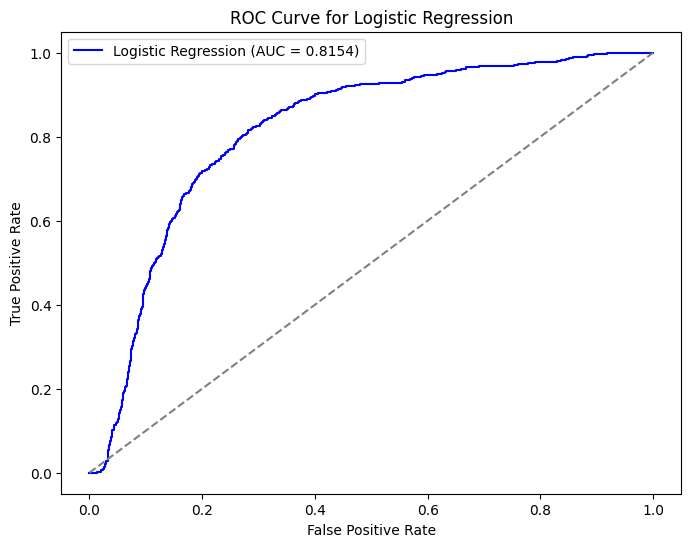

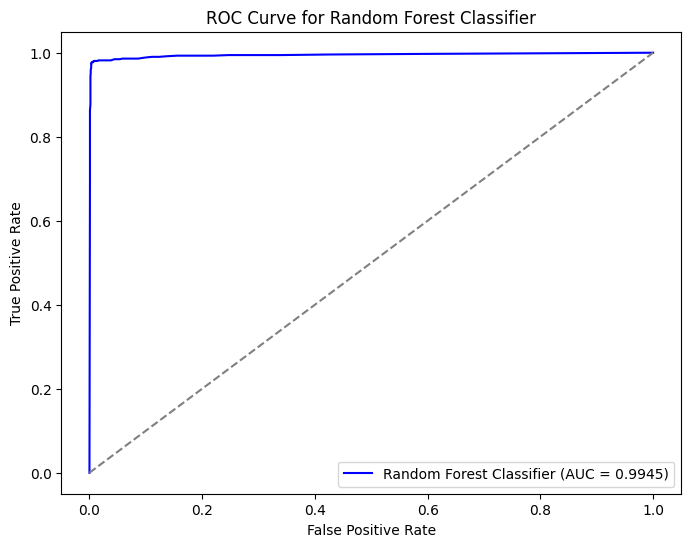

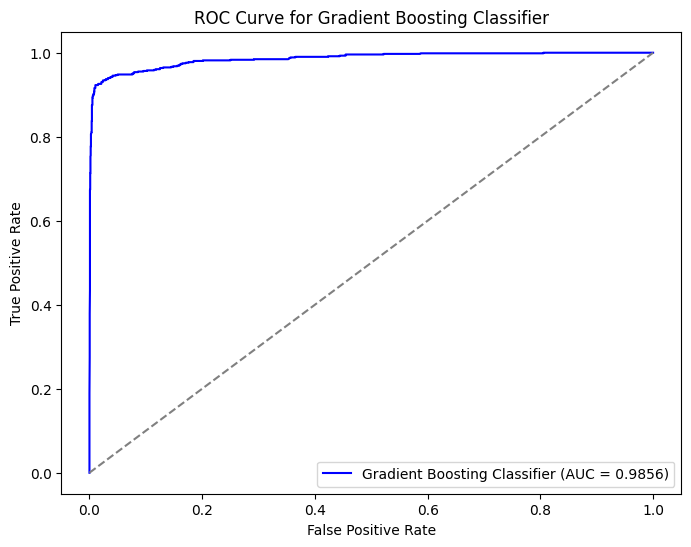

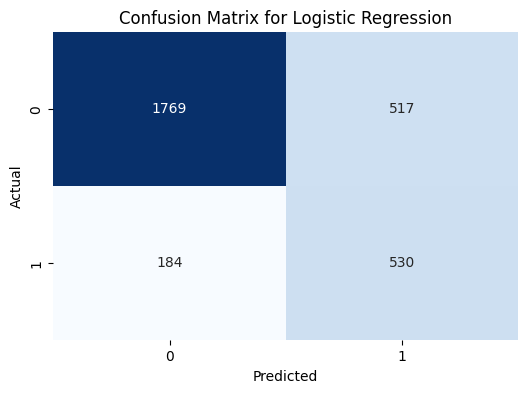

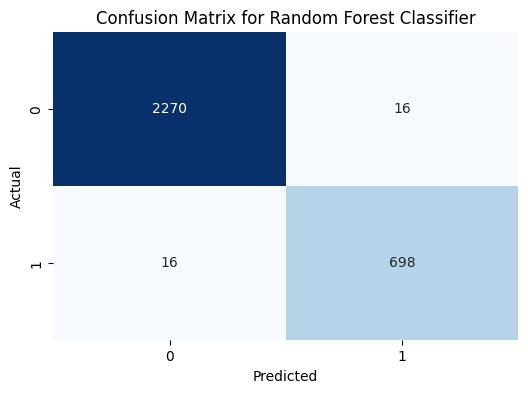

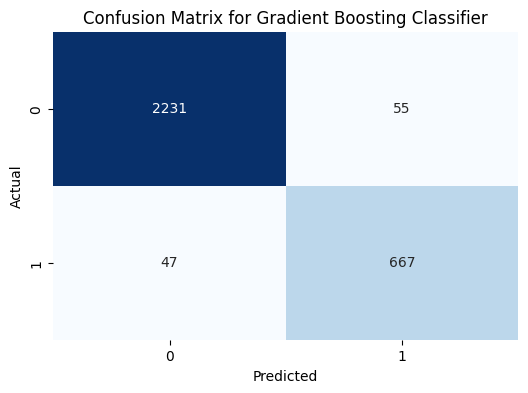

In [23]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

# Function to plot ROC curve
def plot_roc_curve(y_true, y_pred_proba, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc_score = auc(fpr, tpr)

    # Plot the ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})', color='b')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title(f'ROC Curve for {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

    return auc_score

# 6.1 ROC and AUC for each model
# Logistic Regression
lr_model.fit(X_train_smote, y_train_smote)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
auc_lr = plot_roc_curve(y_test, y_pred_proba_lr, "Logistic Regression")

# Random Forest
rf_model.fit(X_train_smote, y_train_smote)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf = plot_roc_curve(y_test, y_pred_proba_rf, "Random Forest Classifier")

# Gradient Boosting Classifier
gb_model.fit(X_train_smote, y_train_smote)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]
auc_gb = plot_roc_curve(y_test, y_pred_proba_gb, "Gradient Boosting Classifier")

# 6.2 Confusion Matrix for each model
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Logistic Regression
y_pred_lr = lr_model.predict(X_test)
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression")

# Random Forest
y_pred_rf = rf_model.predict(X_test)
plot_conf_matrix(y_test, y_pred_rf, "Random Forest Classifier")

# Gradient Boosting
y_pred_gb = gb_model.predict(X_test)
plot_conf_matrix(y_test, y_pred_gb, "Gradient Boosting Classifier")


The model with the highest AUC score, high recall, and a balanced precision is likely the best option.

In this case, focus on recall to capture as many employees at risk of leaving as possible

ROC/AUC:

The plot_roc_curve function plots the ROC curve and calculates the AUC for each model. The higher the AUC, the better the model is at distinguishing between the classes.

Confusion Matrix:

The confusion matrix provides insight into true positives, false negatives, true negatives, and false positives. The function plot_conf_matrix generates the confusion matrix for each model.

Precision vs. Recall:

Recall is particularly important when predicting employee turnover because false negatives (employees predicted to stay but actually leaving) might lead to higher costs and loss of talent.
However, we should also consider precision to ensure we are not misidentifying too many employees as likely to leave when they will stay.

******************************************************************************
Suggest various retention strategies for targeted employees.

7.1.	Using the best model, predict the probability of employee turnover in the test data.

7.2.	Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.

■	Safe Zone (Green) (Score < 20%)

■	Low-Risk Zone (Yellow) (20% < Score < 60%)

■	Medium-Risk Zone (Orange) (60% < Score < 90%)

■	High-Risk Zone (Red) (Score > 90%).


   Employee_ID  Turnover_Probability             Risk_Zone
0        10627              0.005821     Safe Zone (Green)
1         2703              0.952136  High-Risk Zone (Red)
2         6059              0.089794     Safe Zone (Green)
3         3258              0.017795     Safe Zone (Green)
4         4565              0.024528     Safe Zone (Green)


<ipython-input-24-866f5159de8c>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Zone', data=test_results, palette=['green', 'yellow', 'orange', 'red'])


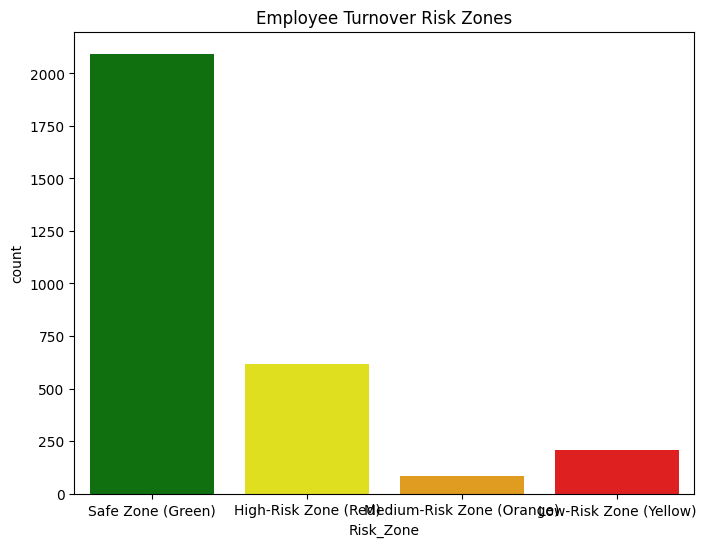

In [24]:
# Predict the probability of employee turnover in the test data using the best model (Assuming Gradient Boosting is best)
best_model = gb_model
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# 7.1 Categorize employees into risk zones
def categorize_risk_zone(prob):
    if prob < 0.2:
        return 'Safe Zone (Green)'
    elif 0.2 <= prob < 0.6:
        return 'Low-Risk Zone (Yellow)'
    elif 0.6 <= prob < 0.9:
        return 'Medium-Risk Zone (Orange)'
    else:
        return 'High-Risk Zone (Red)'

# Create a DataFrame to hold the results
test_results = pd.DataFrame({
    'Employee_ID': X_test.index,  # Assuming the index is Employee ID
    'Turnover_Probability': y_pred_proba_best
})

# Apply categorization
test_results['Risk_Zone'] = test_results['Turnover_Probability'].apply(categorize_risk_zone)

# Display categorized results
print(test_results.head())

# Visualizing the distribution of employees in each risk zone
plt.figure(figsize=(8, 6))
sns.countplot(x='Risk_Zone', data=test_results, palette=['green', 'yellow', 'orange', 'red'])
plt.title('Employee Turnover Risk Zones')
plt.show()


Explanation of Zones and Retention Strategies:

Safe Zone (Green) (Score < 20%):

Description: These employees have a low probability of leaving and are satisfied with their job. They likely enjoy their role, team, and work environment.

Retention Strategy:
Continue providing opportunities for growth and development.

Maintain a positive work environment and recognize their contributions.
Offer regular feedback to keep engagement high.


Low-Risk Zone (Yellow) (20% < Score < 60%):

Description: These employees are somewhat satisfied but could be tempted by better opportunities or improvements in the workplace.

Retention Strategy:
Conduct regular one-on-one meetings to check in on their satisfaction.

Offer mentorship or professional development programs to increase their job engagement.

Ensure competitive compensation and benefits.


Medium-Risk Zone (Orange) (60% < Score < 90%):

Description: These employees are at a moderate risk of leaving and might be disengaged or frustrated with their job.

Retention Strategy:

Identify and address specific pain points, such as workload, management issues, or career stagnation.

Offer incentives for staying, such as bonuses, career growth opportunities, or flexible working conditions.

Engage them in more meaningful projects or roles that align with their interests and skills.


High-Risk Zone (Red) (Score > 90%):

Description: These employees are very likely to leave. They may already be looking for other job opportunities or are dissatisfied with various aspects of their work environment.

Retention Strategy:

Immediate intervention is necessary. Conduct personalized meetings to understand their issues and offer solutions.

Consider offering retention bonuses or addressing their specific concerns (e.g., job role, compensation, team dynamics).

If they are determined to leave, use exit interviews to gain insights and improve future retention strategies.